# A first look at one-step MALA drift

We fix **$p=2$, $h=0.05$, and $V(x)=1+x^2$** throughout. The target density is proportional to $e^{-U(x)}$, where $U(x)=|x|^{2p}=x^4$. Its normalising constant is not needed for acceptance.

Our question is small and local: starting at a fixed $x$, does **one step** increase or decrease $V$ on average? We will inspect proposals, accept/reject decisions, and inward/outward contributions before comparing different starting points. Each experiment draws independent proposals from the same $x$; it is not a trajectory of a Markov chain.

Run the cells in order with a Python kernel containing NumPy and Matplotlib (listed in `requirements.txt`). Launch from the repository root or any directory inside it. These are finite Monte Carlo diagnostics, **not a convergence proof**.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

root = next((q for q in (Path.cwd(), *Path.cwd().parents)
             if (q / "src" / "diagnostics.py").is_file()), None)
if root is None:
    raise RuntimeError("Open this notebook from inside the repository.")
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from src.diagnostics import sample_proposal, alpha, delta
from src.lyapunov import V_poly, dU
from src.utils import mean_and_se

p, h = 2, 0.05
V = lambda z: V_poly(np.asarray(z), m=2)
SEED = 20260924
assert np.allclose(V(np.array([0., 1., 2.])), [1., 2., 5.])
plt.rcParams.update({"figure.figsize": (10, 3.5), "axes.grid": True,
                     "grid.alpha": 0.2})

## 1. Propose a move from one starting point

The implementation uses
$$Y=x-\tfrac12h^2U'(x)+hZ=x-0.005x^3+0.05Z,\qquad Z\sim N(0,1).$$
Thus $h$ is the **standard deviation of proposal noise**; the deterministic displacement uses $h^2$. At $x=1$, the mean proposal is $0.995$. Noise can still move a proposal in either direction.

We measure direction by distance from zero: **inward** means $|Y|<|x|$; **outward** means $|Y|>|x|$. Crossing zero alone does not determine the direction. These exact two-way masks are for this introduction. The repository's `classify_regions` instead uses three regions with relative boundaries $(1\pm\epsilon)|x|$ and a local band, which we do not use here.

Starting point: 1.0; proposal mean: 0.9950; noise SD: 0.05


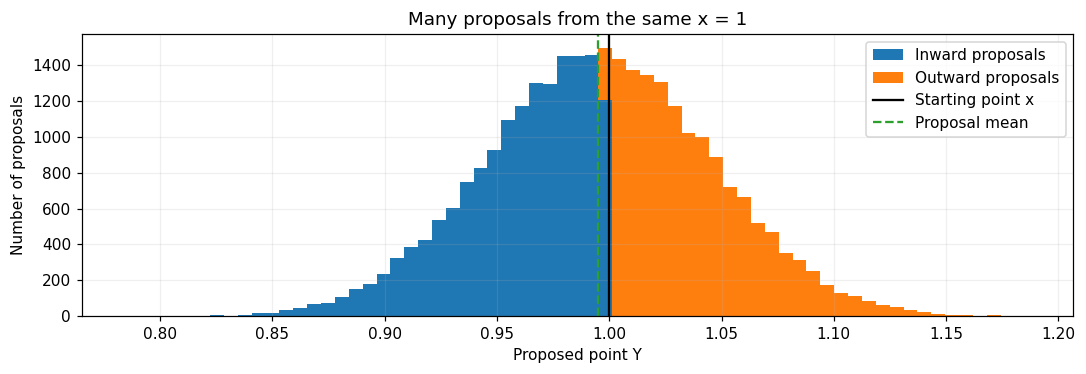

In [2]:
x0 = 1.0
n_demo = 30_000
rng = np.random.default_rng(SEED)
y = sample_proposal(x0, h, p, rng, size=n_demo)
proposal_mean = x0 - 0.5 * h**2 * dU(x0, p)
inward = np.abs(y) < abs(x0)
outward = np.abs(y) > abs(x0)
print(f"Starting point: {x0}; proposal mean: {proposal_mean:.4f}; noise SD: {h}")
fig, ax = plt.subplots()
ax.hist([y[inward], y[outward]], bins=65, stacked=True,
        color=["tab:blue", "tab:orange"], label=["Inward proposals", "Outward proposals"])
ax.axvline(x0, color="black", label="Starting point x")
ax.axvline(proposal_mean, color="tab:green", linestyle="--", label="Proposal mean")
ax.set(xlabel="Proposed point Y", ylabel="Number of proposals", title="Many proposals from the same x = 1")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Accept or stay where we are

A proposal is accepted with probability
$$\alpha(x,y)=\min\!\left(1,\frac{e^{-U(y)}q(y,x)}{e^{-U(x)}q(x,y)}\right).$$
Here $q(x,y)$ is the Gaussian proposal density. The reverse/forward proposal ratio matters because the proposal mean depends on the starting point. We use the existing `alpha` implementation, which computes this ratio through a log correction `delta`.

Draw an independent uniform number $u$ for each proposal. If $u<\alpha(x,Y)$, set $X_1=Y$; otherwise set $X_1=x$. A rejected move has **zero change in $V$**, even if its proposal was far away. The left panel zooms in on the acceptance probabilities; the right shows a selected subset that includes rejections so that staying at $x$ is visible. This subset deliberately overrepresents rejections; use the printed full-sample fraction to assess their frequency.

Mean acceptance probability: 0.999530
Observed accepted fraction: 0.999600; rejections: 12


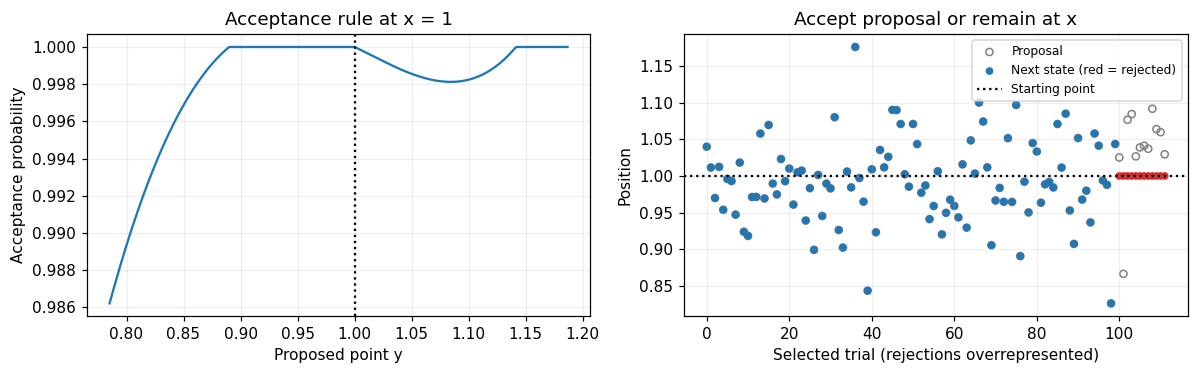

In [3]:
a = alpha(x0, y, h, p)
accepted = rng.random(n_demo) < a
x1 = np.where(accepted, y, x0)
print(f"Mean acceptance probability: {a.mean():.6f}")
print(f"Observed accepted fraction: {accepted.mean():.6f}; rejections: {(~accepted).sum()}")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
y_curve = np.linspace(y.min(), y.max(), 500)
axes[0].plot(y_curve, alpha(x0, y_curve, h, p))
axes[0].axvline(x0, color="black", linestyle=":")
axes[0].set(xlabel="Proposed point y", ylabel="Acceptance probability", title="Acceptance rule at x = 1")
# Select both outcomes for teaching; this is not a representative sample.
indices = np.sort(np.r_[np.flatnonzero(accepted)[:100], np.flatnonzero(~accepted)[:12]])
k = len(indices)
axes[1].scatter(np.arange(k), y[indices], s=22, facecolors="none", edgecolors="gray", label="Proposal")
axes[1].scatter(np.arange(k), x1[indices], s=16, c=np.where(accepted[indices], "tab:blue", "tab:red"), label="Next state (red = rejected)")
axes[1].axhline(x0, color="black", linestyle=":", label="Starting point")
axes[1].set(xlabel="Selected trial (rejections overrepresented)", ylabel="Position", title="Accept proposal or remain at x")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. What is drift, and which moves contribute?

Write $PV(x)=\mathbb E[V(X_1)\mid X_0=x]$. The drift is
$$D(x)=PV(x)-V(x)=\mathbb E[(Y^2-x^2)\alpha(x,Y)].$$
Negative drift means an average decrease in squared distance from zero for this one step. Positive drift means an average increase. It does not mean every move has that direction.

For each proposal calculate $W=(Y^2-x^2)\alpha(x,Y)$. Weighting by the acceptance probability averages out the additional uniform random draw. The realised change $V(X_1)-V(x)$ estimates the same expectation but adds accept/reject noise.

The inward contribution is $\mathbb E[W\,1_{\{|Y|<|x|\}}]$ and the outward contribution is $\mathbb E[W\,1_{\{|Y|>|x|\}}]$. Estimate both by dividing by **all proposals**, not just the number in that region: they include both frequency and size. Their sum is total drift; equal-radius proposals contribute zero.

Probability-weighted drift: -6.721375e-03 (SE 5.75e-04)
Realised one-step drift:    -6.709422e-03 (SE 5.75e-04)


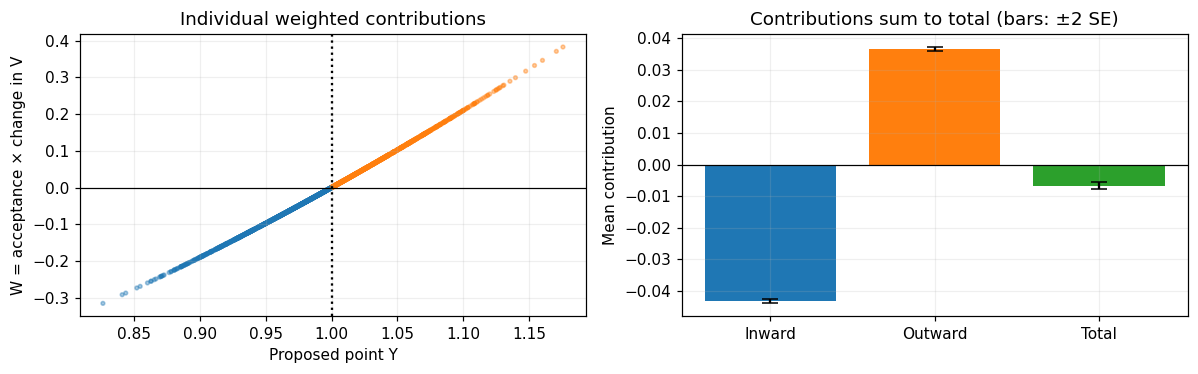

In [4]:
change = V(y) - V(x0)
w = change * a
w_in = np.where(inward, w, 0.0)
w_out = np.where(outward, w, 0.0)
components = [mean_and_se(v) for v in (w_in, w_out, w)]
assert np.allclose(w_in + w_out, w)
assert np.all(w_in <= 0) and np.all(w_out >= 0)
realised_mean, realised_se = mean_and_se(V(x1) - V(x0))
print(f"Probability-weighted drift: {components[2][0]: .6e} (SE {components[2][1]:.2e})")
print(f"Realised one-step drift:    {realised_mean: .6e} (SE {realised_se:.2e})")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].scatter(y[:2000], w[:2000], s=6,
                c=np.where(inward[:2000], "tab:blue", "tab:orange"), alpha=0.4)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].axvline(x0, color="black", linestyle=":")
axes[0].set(xlabel="Proposed point Y", ylabel="W = acceptance × change in V", title="Individual weighted contributions")
axes[1].bar(["Inward", "Outward", "Total"], [v[0] for v in components],
            yerr=[2*v[1] for v in components], capsize=5,
            color=["tab:blue", "tab:orange", "tab:green"])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set(ylabel="Mean contribution", title="Contributions sum to total (bars: ±2 SE)")
plt.tight_layout()
plt.show()

## 4. Repeat at different starting points

The following helper reuses `sample_proposal`, `alpha`, `delta`, `V_poly`, and `mean_and_se`; it only adds the two-way summaries and warning flags needed here. Every starting point gets fresh independent proposals.

A standard error (SE) describes variability seen in this sample. The plotted $\pm2$ SE bands are approximate Monte Carlo uncertainty bands, not rigorous bounds. They can be misleading when important rare proposals never appear.

We flag:

- **Numerical zero:** acceptance or weighted contributions evaluated to exactly zero, or the estimated drift is exactly zero. A finite log acceptance with computed acceptance zero identifies floating-point underflow. Zero is not evidence that the mathematical drift is zero.
- **Low acceptance mass:** $\sum_i\alpha_i<100$, the expected number of accepted moves if we made uniform accept/reject draws on these proposals.
- **Concentrated contributions:** $(\sum_i|W_i|)^2/\sum_iW_i^2<100$. This is a heuristic count of proposals carrying the absolute contribution, not a chain effective sample size or a reliability guarantee.
- **Sign unresolved:** the $\pm2$ SE band includes zero. This differs from an exactly zero estimate.

The thresholds of 100 are illustrative warnings. Even a sample that passes them can miss a rare event. No warning flag certifies accuracy.

In [5]:
def diagnose(x, n, rng):
    proposals = sample_proposal(x, h, p, rng, size=n)
    acceptance = alpha(x, proposals, h, p)
    log_a = np.minimum(-delta(x, proposals, h, p), 0.0)
    dv = V(proposals) - V(x)
    terms = dv * acceptance
    inside = np.abs(proposals) < abs(x)
    outside = np.abs(proposals) > abs(x)
    mu, se = mean_and_se(terms)
    inward_mu = np.where(inside, terms, 0.0).mean()
    outward_mu = np.where(outside, terms, 0.0).mean()
    # Rescale before squaring to avoid additional underflow in this diagnostic.
    scale = np.max(np.abs(terms))
    scaled = np.abs(terms) / scale if scale > 0 else np.zeros_like(terms)
    count = scaled.sum()**2 / np.square(scaled).sum() if scale > 0 else 0.0
    underflow = np.count_nonzero((acceptance == 0) & np.isfinite(log_a))
    product_zero = np.count_nonzero((terms == 0) & (dv != 0) & (acceptance > 0))
    flags = []
    if underflow: flags.append("acceptance underflow")
    if product_zero: flags.append("product underflow")
    if mu == 0: flags.append("zero estimate")
    if se == 0: flags.append("zero SE")
    if acceptance.sum() < 100: flags.append("low acceptance mass")
    if count < 100: flags.append("concentrated contributions")
    if abs(mu) <= 2 * se: flags.append("sign unresolved")
    finite = np.all(np.isfinite(terms)) and np.all(np.isfinite(log_a))
    if not finite: flags.append("non-finite values")
    suspect = bool(underflow or product_zero or mu == 0 or se == 0
                   or acceptance.sum() < 100 or count < 100 or not finite)
    assert np.isclose(inward_mu + outward_mu, mu)
    return dict(x=x, drift=mu, se=se, inward=inward_mu, outward=outward_mu,
                acceptance=acceptance.mean(), zero_fraction=np.mean(acceptance == 0),
                log_a_max=log_a.max(), contribution_count=count,
                suspect=suspect, flags=", ".join(flags) or "no warning triggered")

n_grid = 50_000
x_grid = np.linspace(0, 8, 65)
grid_rng = np.random.default_rng(SEED + 1)
rows = [diagnose(float(x), n_grid, grid_rng) for x in x_grid]
values = lambda key: np.array([r[key] for r in rows])
drift, se = values("drift"), values("se")
print(f"{len(rows)} starting points; {n_grid:,} proposals per point")

65 starting points; 50,000 proposals per point


Grid points with warnings:


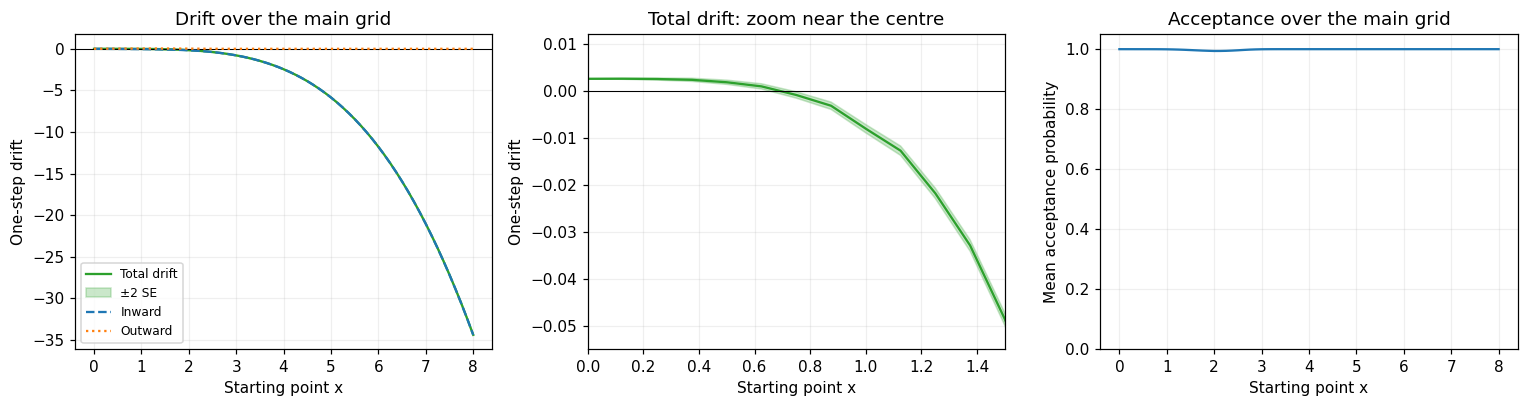

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax in axes[:2]:
    ax.plot(x_grid, drift, color="tab:green", label="Total drift")
    ax.fill_between(x_grid, drift - 2*se, drift + 2*se, color="tab:green", alpha=0.25, label="±2 SE")
    ax.axhline(0, color="black", linewidth=0.7)
    ax.set(xlabel="Starting point x", ylabel="One-step drift")
axes[0].plot(x_grid, values("inward"), color="tab:blue", linestyle="--", label="Inward")
axes[0].plot(x_grid, values("outward"), color="tab:orange", linestyle=":", label="Outward")
axes[0].set_title("Drift over the main grid")
axes[1].set(xlim=(0, 1.5), ylim=(-0.055, 0.012), title="Total drift: zoom near the centre")
axes[0].legend(fontsize=8)
axes[2].plot(x_grid, values("acceptance"))
axes[2].set(xlabel="Starting point x", ylabel="Mean acceptance probability", ylim=(0, 1.05), title="Acceptance over the main grid")
plt.tight_layout()
plt.show()
print("Grid points with warnings:")
for r in rows:
    if r["flags"] != "no warning triggered":
        print(f"x={r['x']:.3f}: {r['flags']}")

At $x=0$, $V$ is minimal, so any nonzero accepted proposal increases it. Positive drift near the centre is therefore natural. On parts of the displayed grid, inward contributions dominate. Read this as a statement about the sampled one-step averages, with the reported uncertainty.

## 5. Stress-test the tails: a flat zero can be misleading

We now extend the starting points deliberately far beyond the main grid. The proposal mean is $x(1-0.005x^2)$: it crosses zero at $x=\sqrt{200}\approx14.14$, and is beyond $-x$ for $x>20$. A large negative deterministic displacement can therefore become **outward in radius**. Acceptance can be extremely small.

The table prints scientific notation to distinguish small values from rounded zeros, and reports the largest sampled log acceptance. A finite log acceptance can be so negative that exponentiating it returns zero. More samples alone do not fix floating-point underflow, and ordinary Monte Carlo may miss the proposals that matter. A zero sample variance can yield zero SE even while the estimate is unreliable.

   x          drift          SE    mean alpha  alpha=0 fraction  max log alpha  flags
  8.0   -3.44052e+01   2.411e-03   1.000e+00             0.000      0.000e+00  no warning triggered
 12.0   -1.32707e+02   1.507e-03   1.000e+00             0.000      0.000e+00  no warning triggered
 14.0   -1.95421e+02   4.399e-02   9.975e-01             0.000      0.000e+00  no warning triggered
 16.0    0.00000e+00   0.000e+00   0.000e+00             1.000     -1.380e+04  acceptance underflow, zero estimate, zero SE, low acceptance mass, concentrated contributions, sign unresolved
 18.0    0.00000e+00   0.000e+00   0.000e+00             1.000     -8.730e+03  acceptance underflow, zero estimate, zero SE, low acceptance mass, concentrated contributions, sign unresolved
 19.0   -1.27062e+02   6.834e-03   1.000e+00             0.000      0.000e+00  no warning triggered
 19.5   -7.14043e+01   7.874e-03   1.000e+00             0.000      0.000e+00  no warning triggered
 20.0   -8.01565e-01   5.236e-03  

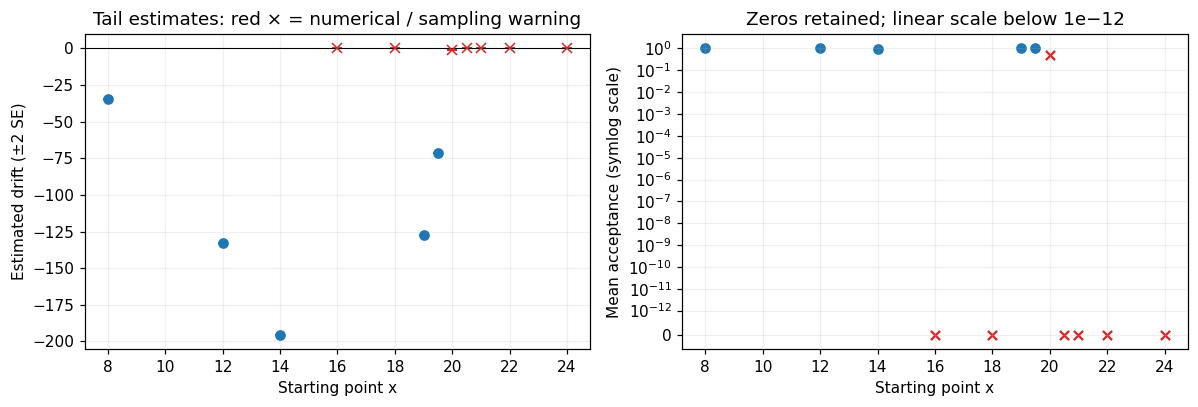

In [7]:
tail_grid = np.array([8., 12., 14., 16., 18., 19., 19.5, 20., 20.5, 21., 22., 24.])
tail_rng = np.random.default_rng(SEED + 2)
tails = [diagnose(float(x), n_grid, tail_rng) for x in tail_grid]
print("   x          drift          SE    mean alpha  alpha=0 fraction  max log alpha  flags")
for r in tails:
    print(f"{r['x']:5.1f} {r['drift']:14.5e} {r['se']:11.3e} "
          f"{r['acceptance']:11.3e} {r['zero_fraction']:17.3f} "
          f"{r['log_a_max']:14.3e}  {r['flags']}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for r in tails:
    color = "tab:red" if r["suspect"] else "tab:blue"
    marker = "x" if r["suspect"] else "o"
    axes[0].errorbar(r["x"], r["drift"], yerr=2*r["se"], fmt=marker, color=color, capsize=3)
    axes[1].scatter(r["x"], r["acceptance"], marker=marker, color=color)
axes[0].axhline(0, color="black", linewidth=0.7)
axes[0].set(xlabel="Starting point x", ylabel="Estimated drift (±2 SE)", title="Tail estimates: red × = numerical / sampling warning")
axes[1].set_yscale("symlog", linthresh=1e-12)
axes[1].set(xlabel="Starting point x", ylabel="Mean acceptance (symlog scale)", title="Zeros retained; linear scale below 1e−12")
plt.tight_layout()
plt.show()

## What this experiment tells us

Proposals, acceptance, and changes in $V$ all matter: frequent inward proposals need not imply appreciable inward drift if they are almost always rejected. Inward and outward **unconditional contributions** add to the one-step drift.

Negative estimates on a finite grid do not establish a drift inequality for every point outside a compact set. Tiny or zero tail estimates do not establish vanishing mathematical drift, and the displayed SEs cannot account for unseen rare proposals. Establishing convergence would require separate mathematical arguments; **this notebook makes no convergence claim**.

## 6. Why acceptance changes in the tails

We keep exactly the same $p=2$, $h=0.05$, and $V(x)=1+x^2$. Compare four starting points:

| $x$ | Proposal mean $m(x)=x-0.005x^3$ | Typical proposal direction |
|---:|---:|:---|
| 12 | 3.360 | inward |
| 16 | −4.480 | inward |
| 19 | −15.295 | inward, despite crossing zero |
| 21 | −25.305 | outward, beyond $-x$ |

An inward **proposal** only satisfies $|y|<|x|$. An **accepted inward move** also survives the Metropolis test. The target ratio favours an inward move, but the reverse proposal density can be so small that the full acceptance probability is tiny. In particular, there is no rule that acceptance must decrease monotonically with $x$.

The three functions we inspect are the proposal density $q(x,y)$, the log acceptance $\log\alpha(x,y)$, and the signed drift integrand
$$g_x(y)=(y^2-x^2)\,q(x,y)\,\alpha(x,y).$$
Its negative area is the inward contribution; its positive area is the outward contribution. The **accepted proposal density** $q\alpha$ integrates to the acceptance probability, not to one. Rejection adds a point mass at $x$ to the transition law, but contributes zero drift.

Broad plots below use base-10 logarithms so tiny values remain visible. Blue means a **negative** integrand and orange a **positive** one; logarithms describe magnitude only. At $y=\pm x$, the drift integrand is exactly zero, so its log magnitude is undefined and omitted. This known algebraic zero is different from floating-point underflow. Dashed lines mark $-x$ and $x$; the dotted green line marks $m(x)$.

The new `src/drift_quadrature.py` imports the existing kernel unchanged and adds log-density and integration helpers. **SciPy is the only new dependency**, added to `requirements.txt`; it supplies root finding, peak location and numerical quadrature.

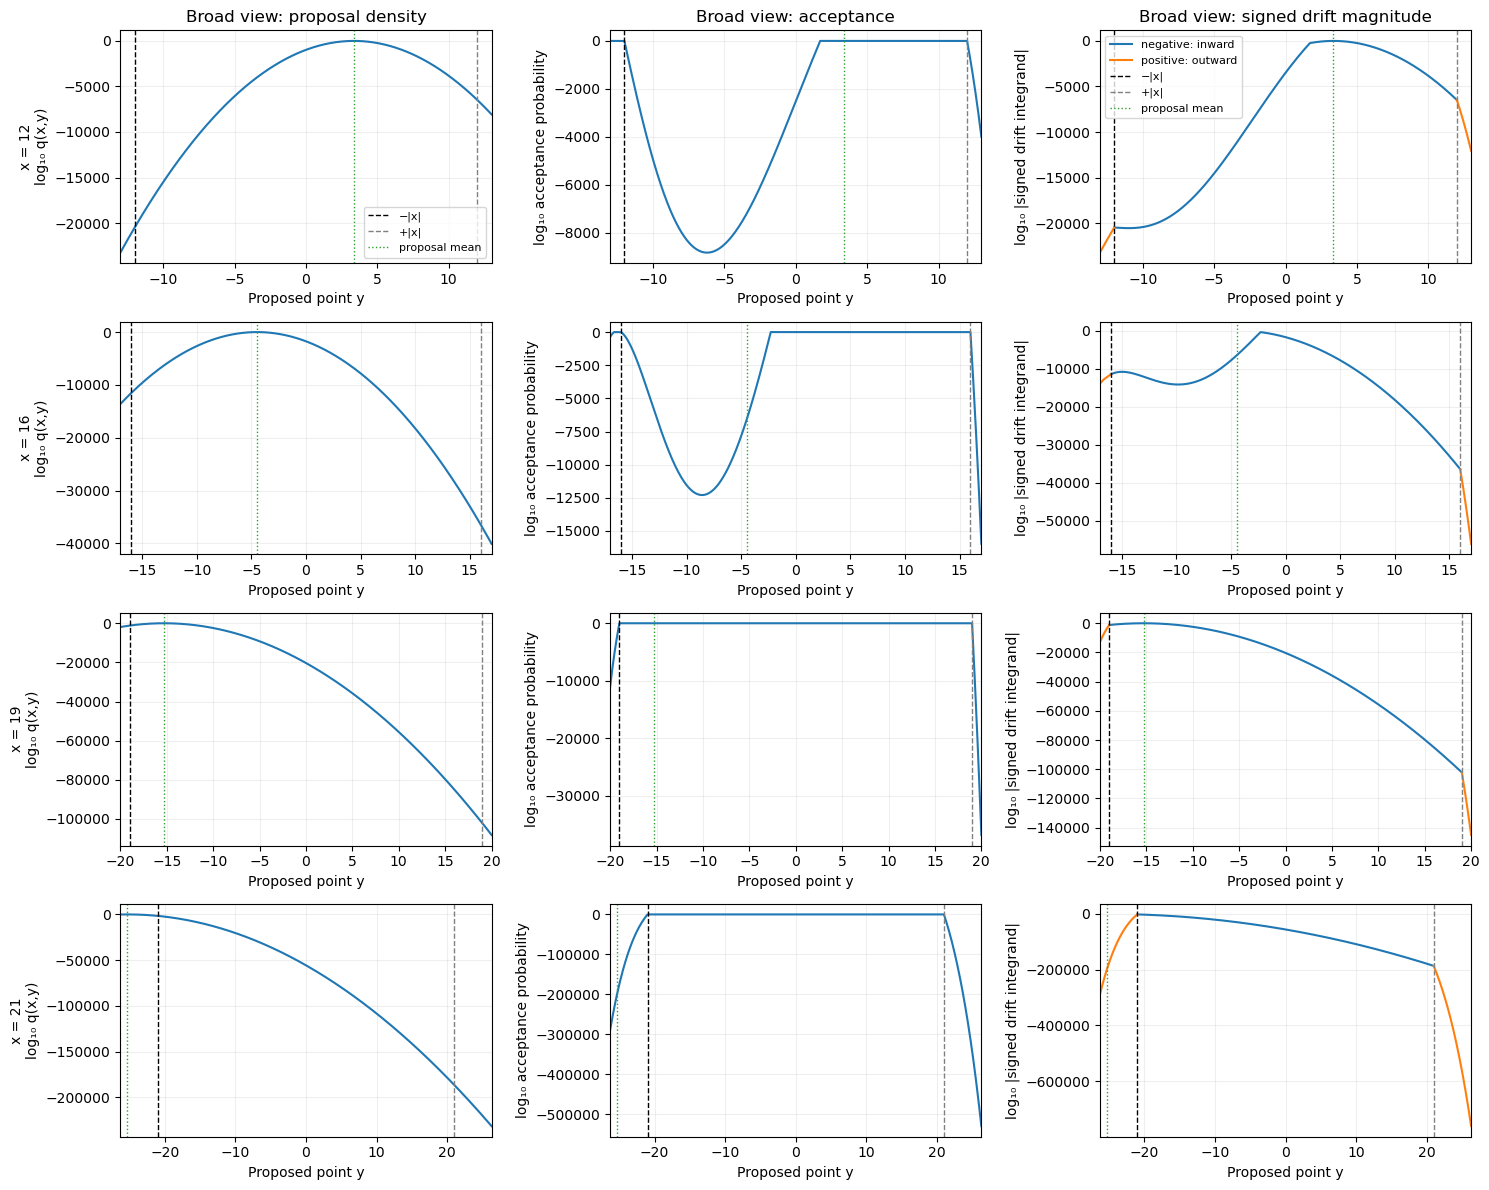

In [8]:
from src.drift_quadrature import (
    H, P, proposal_mean, log_proposal, log_acceptance, log_integrand,
    split_points, integrate_drift, format_log,
)
from scipy.optimize import brentq
from IPython.display import display, Markdown

assert p == P == 2 and h == H == 0.05
compare_x = [12., 16., 19., 21.]
LN10 = np.log(10.)

def mark_locations(ax, x, offset=0.):
    # Only draw in-window markers; off-window markers must not expand a zoom.
    lo, hi = ax.get_xlim()
    for location, color, style, label in [
        (-x, "black", "--", "−|x|"), (x, "gray", "--", "+|x|"),
        (proposal_mean(x), "tab:green", ":", "proposal mean")]:
        if lo <= location-offset <= hi:
            ax.axvline(location-offset, color=color, linestyle=style, lw=1, label=label)

def signed_log_plot(ax, x, ys, offset=0.):
    logs = np.asarray(log_integrand(x, ys, magnitude=True), dtype=float) / LN10
    ax.plot(ys-offset, np.where(np.abs(ys)<x, logs, np.nan), color="tab:blue", label="negative: inward")
    ax.plot(ys-offset, np.where(np.abs(ys)>x, logs, np.nan), color="tab:orange", label="positive: outward")

fig, axes = plt.subplots(4, 3, figsize=(15, 12))
for x, axs in zip(compare_x, axes):
    bound = max(x, abs(proposal_mean(x))) + 1
    ys = np.unique(np.r_[np.linspace(-bound, bound, 6001),
                         split_points(x, bound, magnitude=True)])
    axs[0].plot(ys, np.asarray(log_proposal(x, ys), float)/LN10)
    axs[1].plot(ys, np.asarray(log_acceptance(x, ys), float)/LN10)
    signed_log_plot(axs[2], x, ys)
    for ax in axs:
        ax.set_xlim(-bound, bound)
        mark_locations(ax, x)
        ax.set_xlabel("Proposed point y")
    axs[0].set_ylabel(f"x = {x:g}\nlog₁₀ q(x,y)")
    axs[1].set_ylabel("log₁₀ acceptance probability")
    axs[2].set_ylabel("log₁₀ |signed drift integrand|")
axes[0, 0].set_title("Broad view: proposal density")
axes[0, 1].set_title("Broad view: acceptance")
axes[0, 2].set_title("Broad view: signed drift magnitude")
axes[0, 0].legend(fontsize=8)
axes[0, 2].legend(fontsize=8)
plt.tight_layout()
plt.show()

A broad plot alone is inadequate: proposal noise has standard deviation only $0.05$, and accepted contributions can be much narrower. We therefore show the proposal on its own scale, acceptance near typical proposals, and a close-up of the accepted density's highest peak. The last plot can be far from the proposal mean: **the proposals that dominate accepted mass need not be typical proposals**.

For each close-up we locate candidate peaks from the smooth polynomial log-density branches and their switching points, then choose a window around the peak. Local horizontal axes report the offset $y-y_*$; the actual centre $y_*$ appears in the label. This avoids hiding a peak whose width is tiny relative to its position.

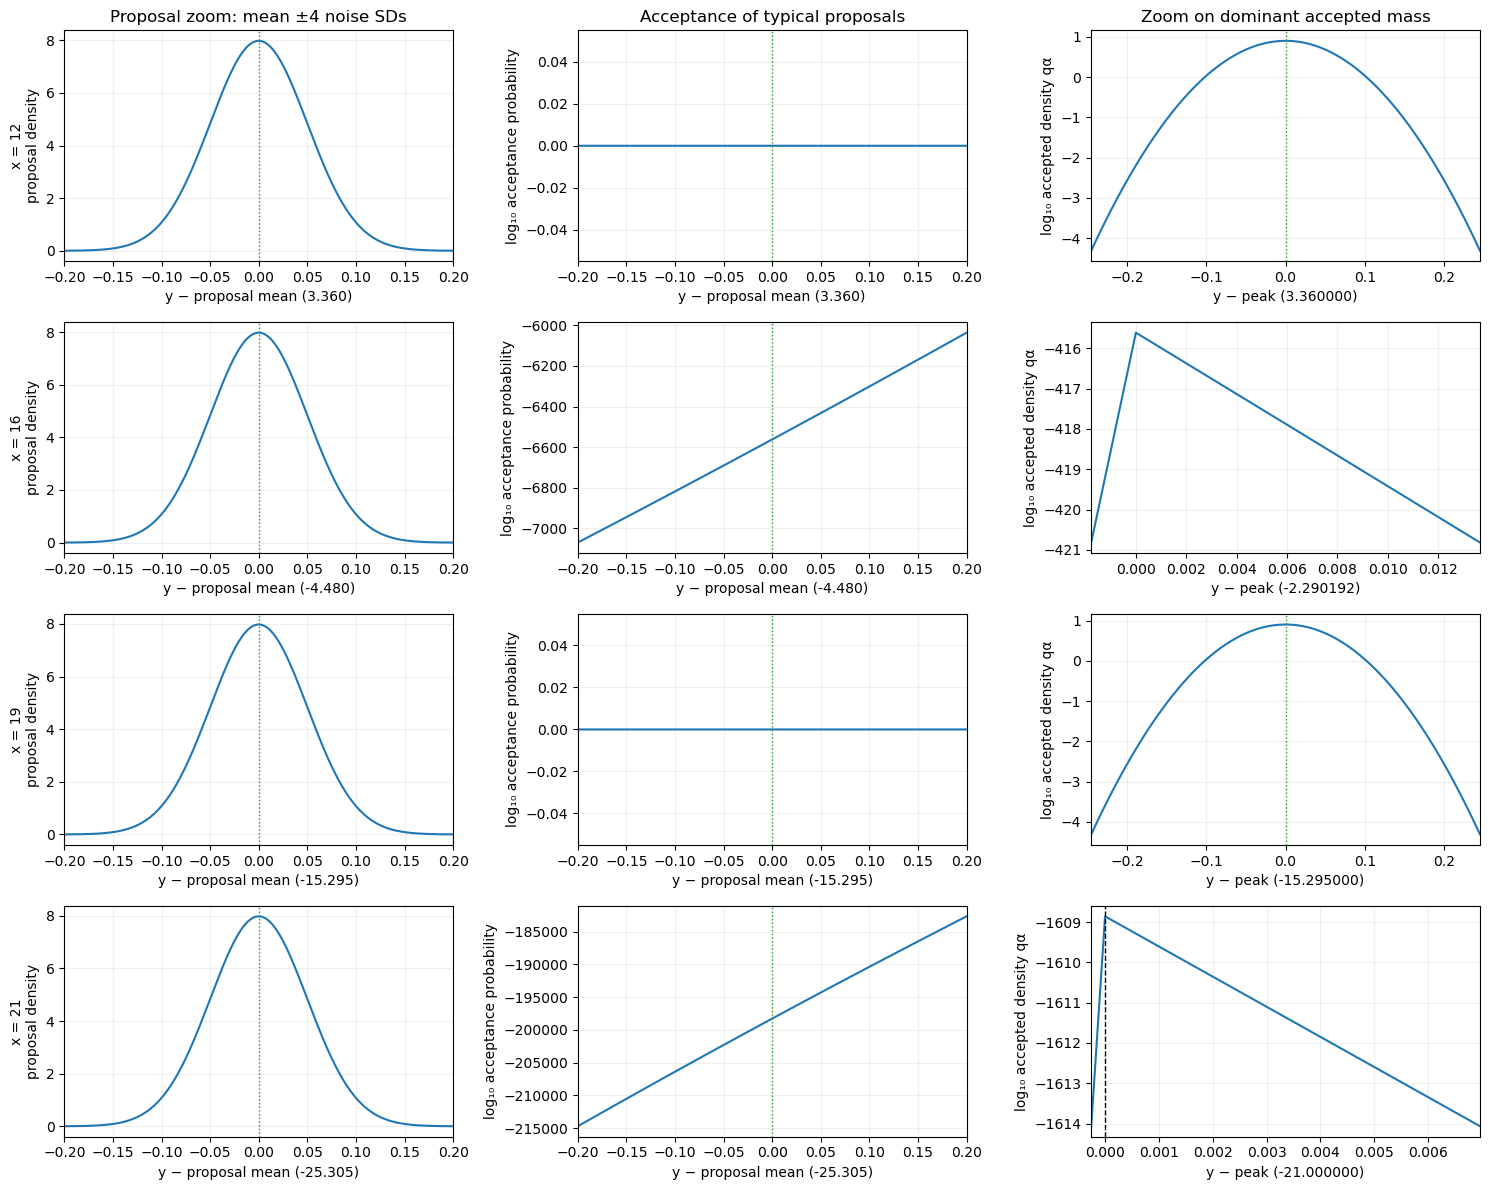

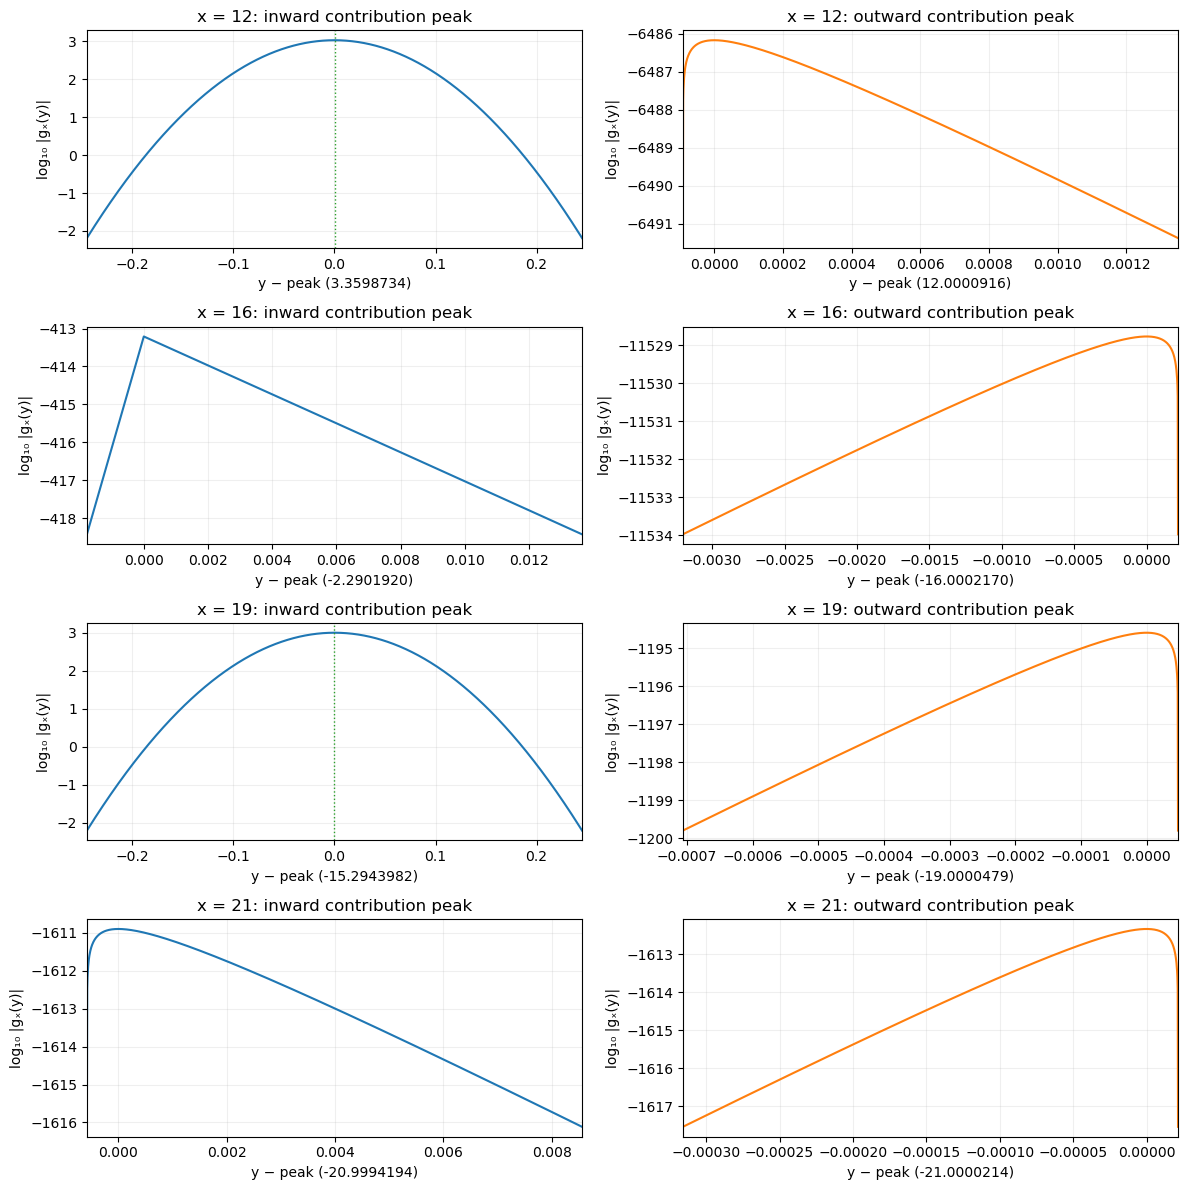

In [9]:
def peak_window(x, component, drop=12.):
    limit = max(x, abs(proposal_mean(x))) + 4
    magnitude = component != "acceptance"
    candidates = split_points(x, limit, magnitude)
    if component == "inward":
        candidates = candidates[np.abs(candidates) < x]
    elif component == "outward":
        candidates = candidates[np.abs(candidates) > x]
    f = lambda y: float(log_integrand(x, y, magnitude))
    peak = max(candidates, key=f)
    if component == "inward":
        bounds = (-x, x)
    elif component == "outward":
        bounds = (-limit, -x) if peak < -x else (x, limit)
    else:
        bounds = (-limit, limit)
    edges = []
    for direction, bound in [(-1, bounds[0]), (1, bounds[1])]:
        step = 1e-8
        while True:
            edge = max(bound, peak-step) if direction < 0 else min(bound, peak+step)
            if f(edge) <= f(peak)-drop:
                edge = brentq(lambda y: f(y)-f(peak)+drop,
                              min(edge, peak), max(edge, peak), xtol=1e-13)
                break
            if edge == bound:
                break
            step *= 2
        edges.append(edge)
    return float(peak), edges[0], edges[1]

fig, axes = plt.subplots(4, 3, figsize=(15, 12))
for x, axs in zip(compare_x, axes):
    mu = proposal_mean(x)
    ys = np.linspace(mu-4*h, mu+4*h, 1200)
    axs[0].plot(ys-mu, np.exp(np.asarray(log_proposal(x, ys), float)))
    axs[1].plot(ys-mu, np.asarray(log_acceptance(x, ys), float)/LN10)
    for ax in axs[:2]:
        ax.set_xlim(-4*h, 4*h)
        mark_locations(ax, x, mu)
        ax.set_xlabel(f"y − proposal mean ({mu:.3f})")
    peak, lo, hi = peak_window(x, "acceptance")
    ys = np.unique(np.r_[np.linspace(lo, hi, 1400), peak])
    axs[2].plot(ys-peak, np.asarray(log_integrand(x, ys), float)/LN10)
    axs[2].set_xlim(lo-peak, hi-peak)
    mark_locations(axs[2], x, peak)
    axs[2].set_xlabel(f"y − peak ({peak:.6f})")
    axs[0].set_ylabel(f"x = {x:g}\nproposal density")
    axs[1].set_ylabel("log₁₀ acceptance probability")
    axs[2].set_ylabel("log₁₀ accepted density qα")
axes[0, 0].set_title("Proposal zoom: mean ±4 noise SDs")
axes[0, 1].set_title("Acceptance of typical proposals")
axes[0, 2].set_title("Zoom on dominant accepted mass")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 2, figsize=(12, 12))
for x, axs in zip(compare_x, axes):
    for component, ax in zip(["inward", "outward"], axs):
        peak, lo, hi = peak_window(x, component)
        ys = np.unique(np.r_[np.linspace(lo, hi, 1600), peak])
        signed_log_plot(ax, x, ys, peak)
        ax.set_xlim(lo-peak, hi-peak)
        mark_locations(ax, x, peak)
        ax.set(xlabel=f"y − peak ({peak:.7f})", ylabel="log₁₀ |gₓ(y)|",
               title=f"x = {x:g}: {component} contribution peak")
plt.tight_layout()
plt.show()

At $x=12$ and $19$, typical proposals are inward and almost always accepted. At $x=16$, proposals near $-4.48$ are inward but their reverse proposal is extremely unlikely; accepted mass instead peaks near $-2.29019$, roughly **44 proposal standard deviations** from the mean. Ordinary Monte Carlo is very unlikely to visit that region.

At $x=21$, typical proposals near $-25.305$ are outward and almost always rejected. Accepted mass concentrates near $-21$, about **86 proposal standard deviations** from the mean. The inward and outward drift peaks sit on opposite sides of this radial boundary with very different widths. Their log heights alone do not give their areas: we need integration.

## 7. Computing drift by numerical integration

**Quadrature** estimates an area by evaluating the function at carefully chosen points and combining those values with weights. Unlike Monte Carlo, it does not wait for a random draw to land in a narrow important region. Adaptive quadrature places more evaluation points where its local error estimate suggests they are needed. It can still miss a peak if the intervals are chosen poorly.

We integrate three **nonnegative** functions separately:
$$A(x)=\int q(x,y)\alpha(x,y)\,dy,$$
$$I_{\rm in}(x)=\int_{-x}^{x}(x^2-y^2)q(x,y)\alpha(x,y)\,dy,$$
$$I_{\rm out}(x)=\int_{|y|>x}(y^2-x^2)q(x,y)\alpha(x,y)\,dy,$$
then subtract: $D(x)=I_{\rm out}(x)-I_{\rm in}(x)$. Here $I_{\rm in}$ is a positive **magnitude**; the signed inward contribution is $-I_{\rm in}$. Keeping these areas separate avoids cancellation inside the quadrature routine.

First verify the kernel. The independent identity
$$\log\alpha(x,y)=\min\{0,\;x^4-y^4+\log q(y,x)-\log q(x,y)\}$$
must agree with `-delta` from the existing implementation. We also check `alpha` where exponentiation is representable, and reproduce `sample_proposal` with identical Gaussian random draws. Extended precision is used for intermediate log arithmetic where NumPy supports it; this is not arbitrary-precision or certified arithmetic.

In [10]:
kernel_checks = []
for x in [1., 6., 12., 16., 19., 21.]:
    ys = np.r_[np.linspace(-30, 30, 401), -x, x,
               proposal_mean(x)+h*np.linspace(-5, 5, 101)]
    direct = np.minimum(np.longdouble(x)**4 - np.asarray(ys, np.longdouble)**4
                        + log_proposal(ys, x) - log_proposal(x, ys), 0)
    existing_log = log_acceptance(x, ys)
    np.testing.assert_allclose(existing_log, direct, rtol=2e-12, atol=1e-9)
    visible = existing_log > -600
    np.testing.assert_allclose(np.exp(existing_log[visible]), alpha(x, ys[visible], h, p),
                               rtol=2e-9, atol=1e-14)
    rng_a, rng_b = np.random.default_rng(91), np.random.default_rng(91)
    np.testing.assert_allclose(sample_proposal(x, h, p, rng_a, 100),
                               proposal_mean(x)+h*rng_b.normal(size=100))
    kernel_checks.append(float(np.max(np.abs(existing_log-direct))))
print("Kernel checks passed at all six points.")
print(f"Largest absolute log-ratio discrepancy: {max(kernel_checks):.3e}")

Kernel checks passed at all six points.
Largest absolute log-ratio discrepancy: 1.397e-09


### How the integration avoids underflow and missed peaks

For an integrand $f\geq0$, let $\ell(y)=\log f(y)$. On each small interval find a peak height $s$, and integrate $\exp(\ell(y)-s)$, whose largest value is about one. Store the result as $s+\log(\text{scaled area})$. Add intervals with log-sum-exp and subtract the final inward/outward areas with a stable signed log difference. **No exponential weights are clipped**, and a finite logarithmic answer is never converted into a reported zero.

The accepted density has the useful form
$$q(x,y)\alpha(x,y)=\min\{q(x,y),\; e^{x^4-y^4}q(y,x)\}.$$
Both log branches are polynomials for this fixed kernel. The helper finds candidate stationary points and branch switches, splits at these points, at the proposal mean and at **both radial boundaries**, and integrates each piece separately. Drift magnitude has its own stationary points because of the factor $|y^2-x^2|$.

We start on $[-L,L]$, with $L=\max\{|x|,|m(x)|\}+4$. Within each smooth piece we integrate the part within 50 natural-log units of its peak and bound the discarded area by **discarded width × maximum discarded height**. This is explicit domain truncation with an error allowance, not replacing small weights by a floor. The check relies on the computed stationary/switching points; numerical root finding and floating-point arithmetic are not a rigorous certification.

Outside $[-L,L]$, the accepted density is at most $e^{x^4-y^4}/(h\sqrt{2\pi})$. The inequality $(L+t)^4\geq L^4+4L^3t$ gives an analytic integrable envelope for the omitted tails. For drift, multiply that envelope by $(L+t)^2+x^2$. These bounds are carried in log form and reported separately from the quadrature error estimate.

We then tighten the quadrature tolerance, add interval midpoints, enlarge $L$ by four units, and increase the retained log-height range. Agreement is evidence of numerical stability, not a proof of exactness. SciPy's [quad documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html) describes the adaptive integrator and its estimated absolute error.

In [11]:
study_x = [1., 6., 12., 16., 19., 21.]
settings = {
    "baseline": dict(rtol=1e-8, padding=4., drop=50.),
    "tighter tolerance": dict(rtol=1e-10, padding=4., drop=50.),
    "extra interval splits": dict(rtol=1e-8, padding=4., drop=50., extra_splits=True),
    "wider finite limits": dict(rtol=1e-8, padding=8., drop=50.),
    "more log-height retained": dict(rtol=1e-8, padding=4., drop=65.),
}
quad_runs = {x: {name: integrate_drift(x, **kw) for name, kw in settings.items()}
             for x in study_x}
quad_results = {x: quad_runs[x]["baseline"] for x in study_x}
components_q = ["acceptance", "inward", "outward"]

# Each variation changes one numerical control, making the comparison interpretable.
sensitivity = {}
lines = ["| x | tighter tol. | extra splits | wider limits | more log-height |",
         "|---:|---:|---:|---:|---:|"]
for x in study_x:
    base = quad_results[x]
    changes = []
    for name in list(settings)[1:]:
        other = quad_runs[x][name]
        changes.append(max(abs(np.expm1(other[k].log_value-base[k].log_value))
                           for k in components_q))
    sensitivity[x] = max(changes)
    lines.append(f"| {x:g} | " + " | ".join(f"{v:.2e}" for v in changes) + " |")
display(Markdown("**Largest relative change among A, I_in and I_out** (not an SE):\n\n"+"\n".join(lines)))

error_lines = ["| x | max quad. relative error estimate | max omitted-area bound / area | sign assessment |",
               "|---:|---:|---:|:---|"]
quad_reliable = {}
for x in study_x:
    r = quad_results[x]
    quad_rel = max(np.exp(r[k].log_quad_error-r[k].log_value) for k in components_q)
    bound_rel = max(np.exp(r[k].log_omitted_bound-r[k].log_value) for k in components_q)
    no_warnings = all(not rr[k].warnings for rr in quad_runs[x].values() for k in components_q)
    # Assess sign against estimated errors AND the observed changes in signed drift.
    drift_change = max(abs(np.expm1(rr["log_abs_drift"]-r["log_abs_drift"]))
                       if rr["sign"] == r["sign"] else np.inf for rr in quad_runs[x].values())
    error_to_drift = np.exp(r["log_drift_error"]-r["log_abs_drift"])
    reliable = (no_warnings and sensitivity[x] < 1e-6 and r["sign_resolved"]
                and error_to_drift+drift_change < 1e-3)
    quad_reliable[x] = reliable
    label = "negative; stable in these checks" if reliable and r["sign"] < 0 else "unresolved"
    error_lines.append(f"| {x:g} | {quad_rel:.2e} | {bound_rel:.2e} | {label} |")
display(Markdown("\n".join(error_lines)))
if not all(quad_reliable.values()):
    print("Some drift signs are unresolved: inspect errors and sensitivity before interpreting them.")

**Largest relative change among A, I_in and I_out** (not an SE):

| x | tighter tol. | extra splits | wider limits | more log-height |
|---:|---:|---:|---:|---:|
| 1 | 0.00e+00 | 4.44e-16 | 0.00e+00 | 0.00e+00 |
| 6 | 2.84e-14 | 2.84e-14 | 2.84e-14 | 1.11e-15 |
| 12 | 1.11e-15 | 2.22e-16 | 0.00e+00 | 5.55e-16 |
| 16 | 0.00e+00 | 0.00e+00 | 0.00e+00 | 1.48e-12 |
| 19 | 2.27e-12 | 3.64e-12 | 0.00e+00 | 8.88e-16 |
| 21 | 3.64e-12 | 3.64e-12 | 0.00e+00 | 7.73e-12 |

| x | max quad. relative error estimate | max omitted-area bound / area | sign assessment |
|---:|---:|---:|:---|
| 1 | 4.72e-12 | 6.16e-22 | negative; stable in these checks |
| 6 | 4.34e-10 | 1.67e-19 | negative; stable in these checks |
| 12 | 8.67e-10 | 1.13e-18 | negative; stable in these checks |
| 16 | 2.34e-10 | 6.61e-19 | negative; stable in these checks |
| 19 | 8.67e-10 | 8.51e-21 | negative; stable in these checks |
| 21 | 4.69e-10 | 1.43e-17 | negative; stable in these checks |

The error columns above concern **numerical integration**, not sampling variability. `quad` estimates the absolute integration error on scaled pieces; we add these estimates and express them relative to each positive area. The omitted-area column covers finite limits and local domain truncation. Neither column fully captures floating-point error or an incorrectly located peak, which is why we also show independent kernel checks and sensitivity checks.

The calculations here resolve a negative drift sign at these six points within the tested numerical settings. If inward and outward areas were almost equal, their difference could be less accurate than either area. The code then reports an **unresolved** sign rather than interpreting a cancelled or underflowed value as exact zero.

## 8. Comparing the two methods

We now draw fresh independent Monte Carlo proposals at the same six points. For every draw we record acceptance weight $\alpha$, inward magnitude $(x^2-Y^2)_+\alpha$, outward magnitude $(Y^2-x^2)_+\alpha$, and their signed difference. All averages divide by the **total sample size**. The total-drift SE is computed directly from the signed contributions, preserving the dependence between inward and outward terms.

Monte Carlo **standard errors** estimate sampling variability under the proposal distribution. Quadrature **error estimates** describe numerical area approximation. They are different quantities and should not be treated as interchangeable confidence intervals. An all-zero Monte Carlo sample has a zero reported SE, but gives no evidence of an exact zero expectation.

In [12]:
n_comparison = 200_000
mc_rng = np.random.default_rng(SEED + 80)
mc_results = {}
for x in study_x:
    ys = sample_proposal(x, h, p, mc_rng, size=n_comparison)
    aa = alpha(x, ys, h, p)
    dv = V(ys)-V(x)
    inward_terms = np.maximum(-dv, 0)*aa
    outward_terms = np.maximum(dv, 0)*aa
    samples = {"acceptance": aa, "inward": inward_terms,
               "outward": outward_terms, "drift": outward_terms-inward_terms}
    stats = {key: mean_and_se(v) for key, v in samples.items()}
    notes = []
    if np.any(aa == 0): notes.append("α underflow observed")
    if np.all(aa == 1): notes.append("sample α=1; rejection unresolved")
    if not np.any(outward_terms): notes.append("outward area not resolved by MC")
    if not np.any(inward_terms): notes.append("inward area not resolved by MC")
    if aa.sum() < 100: notes.append("low sampled acceptance mass")
    stats["notes"] = "; ".join(notes) or "ordinary MC sampling uncertainty"
    mc_results[x] = stats

comparison_lines = ["| x | method | acceptance A | inward magnitude I_in | outward magnitude I_out | total drift D | numerical reliability notes |",
                    "|---:|:---|---:|---:|---:|---:|:---|"]
for x in study_x:
    q = quad_results[x]
    qvalues = [format_log(q[k].log_value) for k in components_q]
    qdrift = format_log(q["log_abs_drift"], q["sign"]) if quad_reliable[x] else "sign unresolved"
    qnote = "stable in four checks; errors above" if quad_reliable[x] else "numerically unresolved; inspect checks"
    comparison_lines.append(f"| {x:g} | quadrature | " + " | ".join(qvalues+[qdrift, qnote]) + " |")
    mc = mc_results[x]
    def mc_text(pair):
        mean, se_mc = pair
        return "0 observed; SE=0 (unresolved)" if mean == 0 and se_mc == 0 else f"{mean:.4e} ± {se_mc:.1e}"
    comparison_lines.append(f"| {x:g} | MC | " + " | ".join(
        [mc_text(mc[k]) for k in components_q+["drift"]]+[mc["notes"]]) + " |")
display(Markdown(f"**MC entries are mean ±1 SE; N = {n_comparison:,}.** Quadrature uses scientific notation even below floating-point range.\n\n"+"\n".join(comparison_lines)))

validation_lines = ["| easier x | A: discrepancy / MC SE | I_in: discrepancy / MC SE | I_out: discrepancy / MC SE | D: discrepancy / MC SE |",
                    "|---:|---:|---:|:---|---:|"]
for x in [1., 6., 12.]:
    q, mc = quad_results[x], mc_results[x]
    ratios = []
    for key in components_q+["drift"]:
        log_value = q["log_abs_drift"] if key == "drift" else q[key].log_value
        sign = q["sign"] if key == "drift" else 1
        mean, mc_se = mc[key]
        if mc_se == 0:
            ratios.append("unresolved by MC")
        else:
            value = sign*float(np.exp(np.longdouble(log_value)))
            z = (mean-value)/mc_se
            ratios.append(f"{z:+.2f}")
            assert abs(z) < 5, "Unexpected easy-point discrepancy: inspect both methods."
    validation_lines.append(f"| {x:g} | " + " | ".join(ratios) + " |")
display(Markdown("**Easy-point validation:** discrepancies measured in Monte Carlo SEs; these are diagnostics, not a formal test.\n\n"+"\n".join(validation_lines)))

**MC entries are mean ±1 SE; N = 200,000.** Quadrature uses scientific notation even below floating-point range.

| x | method | acceptance A | inward magnitude I_in | outward magnitude I_out | total drift D | numerical reliability notes |
|---:|:---|---:|---:|---:|---:|:---|
| 1 | quadrature | 9.995e-1 | 4.362e-2 | 3.611e-2 | -7.517e-3 | stable in four checks; errors above |
| 1 | MC | 9.9953e-01 ± 1.5e-06 | 4.3803e-02 ± 1.3e-04 | 3.6102e-02 ± 1.3e-04 | -7.7008e-03 ± 2.2e-04 | ordinary MC sampling uncertainty |
| 6 | quadrature | 1.000e+0 | 1.179e+1 | 1.050e-105 | -1.179e+1 | stable in four checks; errors above |
| 6 | MC | 1.0000e+00 ± 0.0e+00 | 1.1790e+01 ± 1.1e-03 | 0 observed; SE=0 (unresolved) | -1.1790e+01 ± 1.1e-03 | sample α=1; rejection unresolved; outward area not resolved by MC |
| 12 | quadrature | 1.000e+0 | 1.327e+2 | 1.674e-6490 | -1.327e+2 | stable in four checks; errors above |
| 12 | MC | 1.0000e+00 ± 0.0e+00 | 1.3271e+02 ± 7.5e-04 | 0 observed; SE=0 (unresolved) | -1.3271e+02 ± 7.5e-04 | sample α=1; rejection unresolved; outward area not resolved by MC |
| 16 | quadrature | 3.171e-419 | 7.952e-417 | 1.003e-11532 | -7.952e-417 | stable in four checks; errors above |
| 16 | MC | 0 observed; SE=0 (unresolved) | 0 observed; SE=0 (unresolved) | 0 observed; SE=0 (unresolved) | 0 observed; SE=0 (unresolved) | α underflow observed; outward area not resolved by MC; inward area not resolved by MC; low sampled acceptance mass |
| 19 | quadrature | 1.000e+0 | 1.271e+2 | 3.369e-1199 | -1.271e+2 | stable in four checks; errors above |
| 19 | MC | 1.0000e+00 ± 0.0e+00 | 1.2706e+02 ± 3.4e-03 | 0 observed; SE=0 (unresolved) | -1.2706e+02 ± 3.4e-03 | sample α=1; rejection unresolved; outward area not resolved by MC |
| 21 | quadrature | 8.384e-1613 | 1.972e-1614 | 2.680e-1617 | -1.969e-1614 | stable in four checks; errors above |
| 21 | MC | 0 observed; SE=0 (unresolved) | 0 observed; SE=0 (unresolved) | 0 observed; SE=0 (unresolved) | 0 observed; SE=0 (unresolved) | α underflow observed; outward area not resolved by MC; inward area not resolved by MC; low sampled acceptance mass |

**Easy-point validation:** discrepancies measured in Monte Carlo SEs; these are diagnostics, not a formal test.

| easier x | A: discrepancy / MC SE | I_in: discrepancy / MC SE | I_out: discrepancy / MC SE | D: discrepancy / MC SE |
|---:|---:|---:|:---|---:|
| 1 | +0.04 | +1.35 | -0.05 | -0.83 |
| 6 | unresolved by MC | -0.77 | unresolved by MC | +0.77 |
| 12 | unresolved by MC | -1.51 | unresolved by MC | +1.51 |

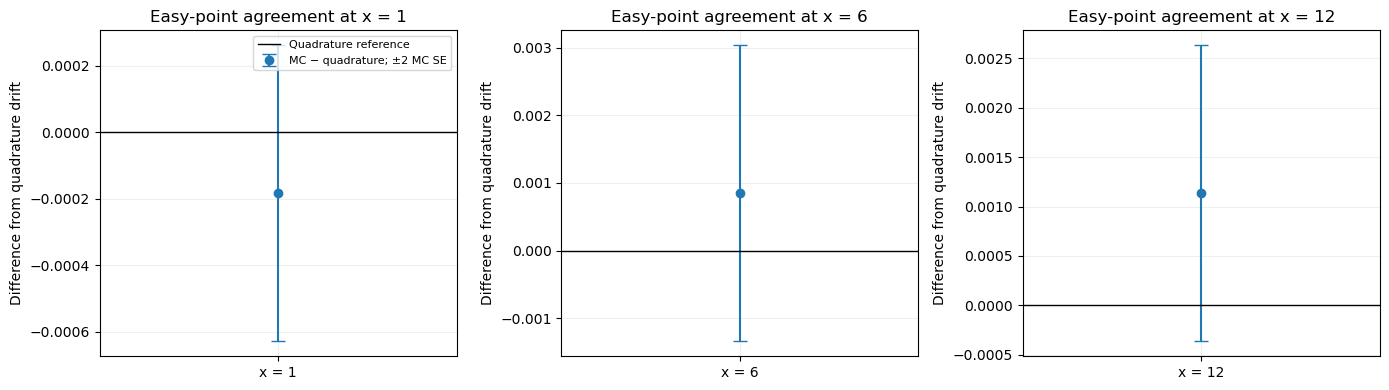

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, x in zip(axes, [1., 6., 12.]):
    q, mc = quad_results[x], mc_results[x]
    q_drift = q["sign"]*np.exp(q["log_abs_drift"])
    mean, mc_se = mc["drift"]
    ax.errorbar([0], [mean-q_drift], yerr=[2*mc_se], fmt="o", capsize=5, label="MC − quadrature; ±2 MC SE")
    ax.axhline(0, color="black", linewidth=1, label="Quadrature reference")
    ax.set(xticks=[0], xticklabels=[f"x = {x:g}"], ylabel="Difference from quadrature drift",
           title=f"Easy-point agreement at x = {x:g}")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

### Interpretation and limits

- **At $x=1,6,12$**, Monte Carlo and quadrature agree for the contributions that Monte Carlo can measure and for total drift within ordinary sampling variation. At $6$ and $12$, outward contributions are too rare for this Monte Carlo sample, even though total drift is well estimated. An acceptance value printed as `1.000e+0` is rounded; it does not assert exact acceptance probability one.
- **At $x=19$**, the typical proposal is again inward and nearly always accepted. Acceptance need not change monotonically as the starting point moves into the tails.
- **At $x=16$**, quadrature finds acceptance about $3.17\times10^{-419}$ and drift about $-7.95\times10^{-417}$. The all-zero Monte Carlo result misses rare accepted inward moves. It is not a competing estimate with zero uncertainty.
- **At $x=21$**, both drift areas are extremely small but resolved in log form: inward is about $1.97\times10^{-1614}$ and outward about $2.68\times10^{-1617}$. Their difference is negative, about $-1.97\times10^{-1614}$, and stable under the numerical checks. Monte Carlo cannot resolve either area with this sample size.

These checks support the displayed **one-step numerical values at the selected starting points**. Quadrature error estimates are not rigorous enclosures; the sign assessments depend on the numerical kernel evaluation, peak discovery and tested integration settings. Direct Monte Carlo confirmation of the very small tail areas remains unavailable here. No conclusion is established for every larger $x$, and these calculations do not establish a uniform drift inequality, a convergence rate, or a convergence proof.